In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/train.csv")

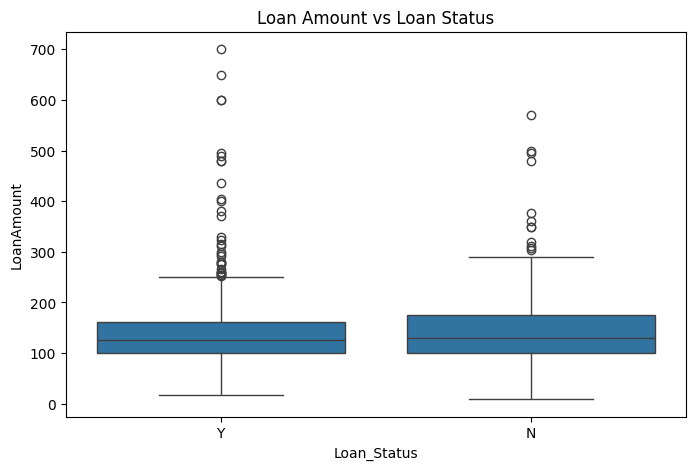

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)

plt.title("Loan Amount vs Loan Status")

plt.show()

In [7]:
import pandas as pd

df = pd.read_csv("/content/train.csv")

print(df.shape)
print(df['Loan_Status'].value_counts())

(614, 13)
Loan_Status
Y    422
N    192
Name: count, dtype: int64


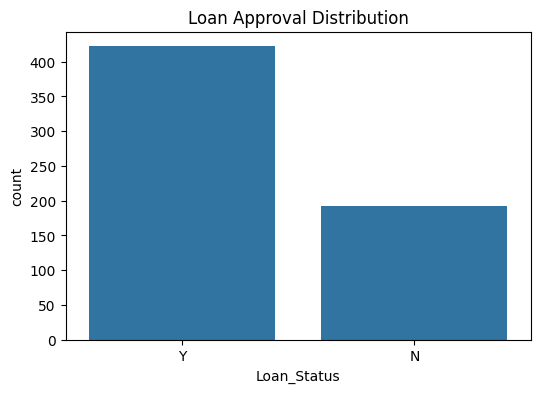

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

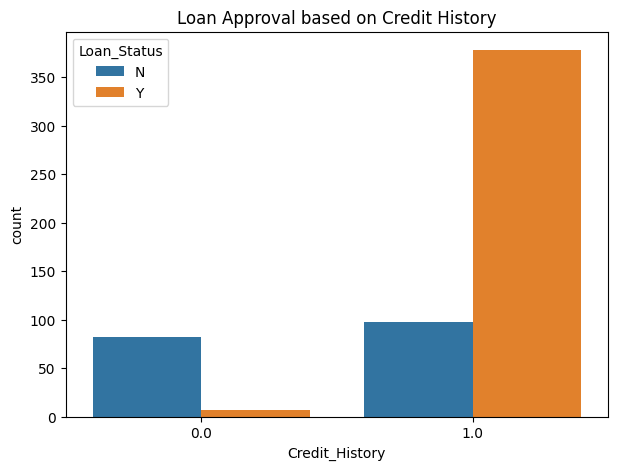

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Loan Approval based on Credit History")

plt.show()

In [10]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [11]:
# Categorical columns
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# Numerical columns
numerical_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [13]:
df.drop('Loan_ID', axis=1, inplace=True)

In [14]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
df['TotalIncome'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

In [16]:
df[['ApplicantIncome', 'CoapplicantIncome', 'TotalIncome']].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [17]:
df['Loan_Status'] = df['Loan_Status'].map({
    'Y': 1,
    'N': 0
})

In [18]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
1,422
0,192


In [19]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 12)
y shape: (614,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 12)
Testing data: (123, 12)


In [21]:
categorical_features = X.select_dtypes(
    include=['object']
).columns

numerical_features = X.select_dtypes(
    exclude=['object']
).columns

print("Categorical features:")
print(list(categorical_features))

print("\nNumerical features:")
print(list(numerical_features))

Categorical features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

Numerical features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome']


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression())
    ]
)

In [24]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [25]:
y_pred = logistic_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.8617886178861789
Accuracy percentage: 86.1788617886179


In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy %:", rf_accuracy * 100)

Random Forest Accuracy: 0.8373983739837398
Random Forest Accuracy %: 83.73983739837398


In [29]:
df_original = df.copy()

In [30]:
df_property = df.copy()

In [31]:
import numpy as np

np.random.seed(42)

df_property['Land_Area'] = np.random.randint(
    600, 5001, size=len(df_property)
)

df_property['Property_Value'] = np.random.randint(
    10, 101, size=len(df_property)
) * 100000

df_property['Building_Age'] = np.random.randint(
    0, 41, size=len(df_property)
)

df_property['Building_Condition'] = np.random.choice(
    ['Poor', 'Average', 'Good'],
    size=len(df_property),
    p=[0.20, 0.50, 0.30]
)

df_property['Soil_Type'] = np.random.choice(
    ['Sandy', 'Clay', 'Loamy'],
    size=len(df_property)
)

df_property['Flood_Risk'] = np.random.choice(
    ['Low', 'Medium', 'High'],
    size=len(df_property),
    p=[0.50, 0.35, 0.15]
)

df_property['Road_Access'] = np.random.choice(
    ['Poor', 'Average', 'Good'],
    size=len(df_property),
    p=[0.15, 0.45, 0.40]
)

df_property['Water_Availability'] = np.random.choice(
    ['Poor', 'Average', 'Good'],
    size=len(df_property),
    p=[0.15, 0.40, 0.45]
)

df_property['Legal_Status'] = np.random.choice(
    ['Clear', 'Disputed'],
    size=len(df_property),
    p=[0.90, 0.10]
)

In [32]:
df_property[
    [
        'Land_Area',
        'Property_Value',
        'Building_Age',
        'Building_Condition',
        'Soil_Type',
        'Flood_Risk',
        'Road_Access',
        'Water_Availability',
        'Legal_Status'
    ]
].head(10)

,Land_Area,Property_Value,Building_Age,Building_Condition,Soil_Type,Flood_Risk,Road_Access,Water_Availability,Legal_Status
0,1460,2500000,20,Average,Loamy,Medium,Good,Good,Clear
1,4372,1700000,21,Poor,Clay,Medium,Average,Average,Clear
2,3692,1300000,6,Average,Loamy,High,Average,Good,Clear
3,1066,1300000,13,Good,Clay,Low,Average,Average,Clear
4,4044,6500000,14,Average,Sandy,High,Good,Good,Clear
5,3771,3400000,6,Average,Sandy,Medium,Average,Good,Clear
6,3519,7600000,8,Good,Loamy,Medium,Average,Average,Clear
7,730,7600000,7,Good,Sandy,Medium,Average,Good,Clear
8,2285,3600000,22,Good,Loamy,Medium,Good,Average,Clear
9,1369,4100000,28,Good,Sandy,Low,Average,Average,Clear


In [33]:
df_property['Property_Risk_Score'] = 0

# Building condition
df_property['Property_Risk_Score'] += df_property['Building_Condition'].map({
    'Good': 0,
    'Average': 1,
    'Poor': 2
})

# Flood risk
df_property['Property_Risk_Score'] += df_property['Flood_Risk'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

# Road access
df_property['Property_Risk_Score'] += df_property['Road_Access'].map({
    'Good': 0,
    'Average': 1,
    'Poor': 2
})

# Water availability
df_property['Property_Risk_Score'] += df_property['Water_Availability'].map({
    'Good': 0,
    'Average': 1,
    'Poor': 2
})

# Legal status
df_property['Property_Risk_Score'] += df_property['Legal_Status'].map({
    'Clear': 0,
    'Disputed': 3
})

In [34]:
df_property[
    [
        'Building_Condition',
        'Flood_Risk',
        'Road_Access',
        'Water_Availability',
        'Legal_Status',
        'Property_Risk_Score'
    ]
].head(10)

,Building_Condition,Flood_Risk,Road_Access,Water_Availability,Legal_Status,Property_Risk_Score
0,Average,Medium,Good,Good,Clear,2
1,Poor,Medium,Average,Average,Clear,5
2,Average,High,Average,Good,Clear,4
3,Good,Low,Average,Average,Clear,2
4,Average,High,Good,Good,Clear,3
5,Average,Medium,Average,Good,Clear,3
6,Good,Medium,Average,Average,Clear,3
7,Good,Medium,Average,Good,Clear,2
8,Good,Medium,Good,Average,Clear,2
9,Good,Low,Average,Average,Clear,2


In [35]:
df_property['Loan_to_Property_Ratio'] = (
    (df_property['LoanAmount'] * 100000) /
    df_property['Property_Value']
)

In [36]:
df_property[
    [
        'LoanAmount',
        'Property_Value',
        'Loan_to_Property_Ratio'
    ]
].head(10)

,LoanAmount,Property_Value,Loan_to_Property_Ratio
0,128.0,2500000,5.120000
1,128.0,1700000,7.529412
2,66.0,1300000,5.076923
3,120.0,1300000,9.230769
4,141.0,6500000,2.169231
5,267.0,3400000,7.852941
6,95.0,7600000,1.250000
7,158.0,7600000,2.078947
8,168.0,3600000,4.666667
9,349.0,4100000,8.512195


In [37]:
X_property = df_property.drop('Loan_Status', axis=1)
y_property = df_property['Loan_Status']

In [38]:
categorical_features_property = X_property.select_dtypes(
    include=['object']
).columns

numerical_features_property = X_property.select_dtypes(
    exclude=['object']
).columns

print("Categorical:")
print(list(categorical_features_property))

print("\nNumerical:")
print(list(numerical_features_property))

Categorical:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Building_Condition', 'Soil_Type', 'Flood_Risk', 'Road_Access', 'Water_Availability', 'Legal_Status']

Numerical:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'Land_Area', 'Property_Value', 'Building_Age', 'Property_Risk_Score', 'Loan_to_Property_Ratio']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_property = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features_property
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features_property
        )
    ]
)

In [40]:
from sklearn.model_selection import train_test_split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_property,
    y_property,
    test_size=0.2,
    random_state=42,
    stratify=y_property
)

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

property_logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_property),
        ('model', LogisticRegression())
    ]
)

property_logistic_model.fit(X_train_p, y_train_p)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'Land_Area',
       'Property_Value', 'Building_Age', 'Property_Risk_Score',
       'Loan_to_Property_Ratio'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Building_Condition', 'Soil_Type', 'Flood_Risk',
       'Road_Access', 'Water_Availability', 'Legal_Status'],
      dtype='object'))])),
                ('model', LogisticRegression())])

In [42]:
y_pred_property = property_logistic_model.predict(X_test_p)

In [43]:
from sklearn.metrics import accuracy_score

property_accuracy = accuracy_score(
    y_test_p,
    y_pred_property
)

print("Enhanced Model Accuracy:", property_accuracy)
print("Enhanced Model Accuracy %:", property_accuracy * 100)

Enhanced Model Accuracy: 0.8536585365853658
Enhanced Model Accuracy %: 85.36585365853658


In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [45]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[22 16]
 [ 1 84]]


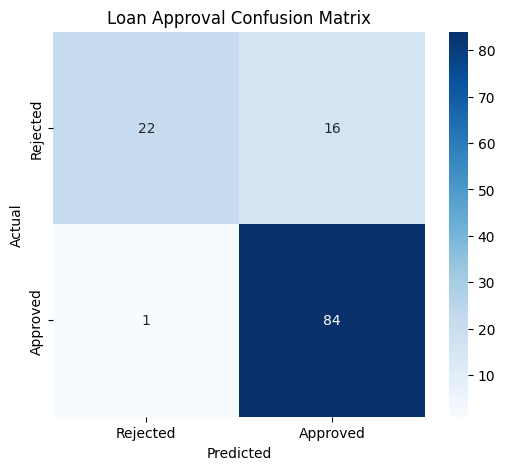

In [46]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Loan Approval Confusion Matrix')

plt.show()

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

dt_pred = decision_tree_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy %:", dt_accuracy * 100)

Decision Tree Accuracy: 0.8455284552845529
Decision Tree Accuracy %: 84.5528455284553


In [48]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.85      0.61      0.71        38
           1       0.84      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.78      0.80       123
weighted avg       0.85      0.85      0.84       123



In [49]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Decision Tree',
        'Enhanced Logistic Regression'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test_p, y_pred_property)
    ]
})

results['Accuracy %'] = results['Accuracy'] * 100

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Accuracy %
0,Logistic Regression,0.861789,86.178862
3,Enhanced Logistic Regression,0.853659,85.365854
2,Decision Tree,0.845528,84.552846
1,Random Forest,0.837398,83.739837


In [50]:
best_model_name = results.loc[
    results['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = results['Accuracy'].max() * 100

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy, "%")

Best Model: Logistic Regression
Best Accuracy: 86.1788617886179 %


In [51]:
import joblib

joblib.dump(
    logistic_model,
    '/content/loan_approval_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [52]:
def predict_loan(applicant_data):
    prediction = logistic_model.predict(applicant_data)

    if prediction[0] == 1:
        return "Loan Approved"
    else:
        return "Loan Rejected"

In [53]:
new_applicant = pd.DataFrame({
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['1'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [6000],
    'CoapplicantIncome': [2000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],
    'Property_Area': ['Urban'],
    'TotalIncome': [8000]
})

In [54]:
new_applicant = pd.DataFrame({
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['1'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [6000],
    'CoapplicantIncome': [2000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],
    'Property_Area': ['Urban'],
    'TotalIncome': [8000]
})

In [55]:
prediction = logistic_model.predict(new_applicant)

if prediction[0] == 1:
    print("🏠 LOAN APPROVED")
else:
    print("❌ LOAN REJECTED")

🏠 LOAN APPROVED


In [56]:
!pip install -q gradio

In [57]:
def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_term,
    credit_history,
    property_area
):

    total_income = applicant_income + coapplicant_income

    new_applicant = pd.DataFrame({
        'Gender': [gender],
        'Married': [married],
        'Dependents': [dependents],
        'Education': [education],
        'Self_Employed': [self_employed],
        'ApplicantIncome': [applicant_income],
        'CoapplicantIncome': [coapplicant_income],
        'LoanAmount': [loan_amount],
        'Loan_Amount_Term': [loan_term],
        'Credit_History': [credit_history],
        'Property_Area': [property_area],
        'TotalIncome': [total_income]
    })

    prediction = logistic_model.predict(new_applicant)[0]

    probability = logistic_model.predict_proba(new_applicant)[0][1]

    if prediction == 1:
        result = "🟢 LOAN APPROVED"
    else:
        result = "🔴 LOAN REJECTED"

    return f"{result}\nApproval probability: {probability:.2%}"

In [58]:
import gradio as gr

app = gr.Interface(
    fn=predict_loan,

    inputs=[
        gr.Dropdown(
            ["Male", "Female"],
            label="Gender"
        ),

        gr.Dropdown(
            ["Yes", "No"],
            label="Married"
        ),

        gr.Dropdown(
            ["0", "1", "2", "3+"],
            label="Dependents"
        ),

        gr.Dropdown(
            ["Graduate", "Not Graduate"],
            label="Education"
        ),

        gr.Dropdown(
            ["Yes", "No"],
            label="Self Employed"
        ),

        gr.Number(
            label="Applicant Income"
        ),

        gr.Number(
            label="Co-applicant Income"
        ),

        gr.Number(
            label="Loan Amount"
        ),

        gr.Number(
            label="Loan Amount Term"
        ),

        gr.Dropdown(
            [0, 1],
            label="Credit History"
        ),

        gr.Dropdown(
            ["Urban", "Semiurban", "Rural"],
            label="Property Area"
        )
    ],

    outputs=gr.Textbox(
        label="Prediction"
    ),

    title="🏠 Smart Home Loan Approval Predictor",

    description=(
        "Predict loan approval based on applicant "
        "financial and demographic information."
    )
)

In [59]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cc5864000754c6598.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [60]:
!pip install -q gradio

In [61]:
def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_term,
    credit_history,
    property_area
):

    total_income = applicant_income + coapplicant_income

    new_applicant = pd.DataFrame({
        'Gender': [gender],
        'Married': [married],
        'Dependents': [dependents],
        'Education': [education],
        'Self_Employed': [self_employed],
        'ApplicantIncome': [applicant_income],
        'CoapplicantIncome': [coapplicant_income],
        'LoanAmount': [loan_amount],
        'Loan_Amount_Term': [loan_term],
        'Credit_History': [credit_history],
        'Property_Area': [property_area],
        'TotalIncome': [total_income]
    })

    prediction = logistic_model.predict(new_applicant)[0]

    probability = logistic_model.predict_proba(new_applicant)[0][1]

    if prediction == 1:
        result = "🟢 LOAN APPROVED"
    else:
        result = "🔴 LOAN REJECTED"

    return f"{result}\nApproval probability: {probability:.2%}"

In [62]:
import gradio as gr

app = gr.Interface(
    fn=predict_loan,

    inputs=[
        gr.Dropdown(["Male", "Female"], label="Gender"),

        gr.Dropdown(["Yes", "No"], label="Married"),

        gr.Dropdown(["0", "1", "2", "3+"], label="Dependents"),

        gr.Dropdown(
            ["Graduate", "Not Graduate"],
            label="Education"
        ),

        gr.Dropdown(["Yes", "No"], label="Self Employed"),

        gr.Number(label="Applicant Income"),

        gr.Number(label="Co-applicant Income"),

        gr.Number(label="Loan Amount"),

        gr.Number(label="Loan Amount Term"),

        gr.Dropdown([0, 1], label="Credit History"),

        gr.Dropdown(
            ["Urban", "Semiurban", "Rural"],
            label="Property Area"
        )
    ],

    outputs=gr.Textbox(label="Prediction"),

    title="🏠 Smart Home Loan Approval Predictor",

    description="Enter applicant details to predict loan approval."
)

In [63]:
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ec33928fae958324d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
